# StyleGAN2 — Weight Modulation, Demodulation, Path Length

This notebook implements a simplified **StyleGAN2** (Karras et al., 2020), following Module 19.

StyleGAN introduced the `z -> w -> style` pipeline and AdaIN-based style injection. But AdaIN is problematic: it normalizes feature activations and then injects style *on top of* the normalized features. This produces a characteristic "droplet" artifact and discards information the convolution had learned.

StyleGAN2's solution is to move style control **into the convolution itself**, before any feature normalization. Three architectural moves:

1. **Weight modulation**: scale the convolution weights by the style vector (per input channel).
2. **Weight demodulation**: re-normalize the modulated weights so the activation magnitude stays bounded regardless of style.
3. **Path length regularization (PLR)**: penalize the Generator when small changes in the latent space produce wildly inconsistent changes in image space.

StyleGAN2 also **removes progressive growing** (covered in Module 17). The architecture is trained at the target resolution from the start.

We keep the StyleGAN structure (mapping network, learned constant, hierarchical synthesis blocks) but replace AdaIN with mod/demod convolutions and add PLR to the Generator objective.

## Implementation Plan

- **Mapping network**: same as StyleGAN — 4-layer MLP from `z` (100-D) to `w` (128-D), LeakyReLU activations.
- **Modulated conv**: a custom `ModulatedConv2d` that takes a feature map and a style vector, scales the conv weights by the style (per input channel), normalizes the result so the per-output-channel weight norm is 1, then applies the convolution. Implemented via `F.unfold` + batched matmul so we keep per-sample style control without paying Python-loop costs.
- **Synthesis network**: learned 4x4 constant + four mod-conv blocks at resolutions `4`, `8`, `16`, `32`. No AdaIN. One final `to_rgb` `1x1` conv.
- **Path length regularization**: every `pl_every` iterations, sample a fresh batch, compute `(fake * y).sum()` backward through the mapping output `w`, take the norm of `d_w`, and penalize `(norm - a_running)^2` where `a_running` is an EMA of the path length.
- **Discriminator**: standard PatchGAN (output `4x4` logit map for 32x32 input).
- **Loss**: `BCEWithLogitsLoss` for adversarial + PLR term (weight `pl_weight = 1.0`).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

torch.manual_seed(42)
np.random.seed(42)

## 1. Setup and Hyperparameters

The new piece is `pl_weight` — how strongly to penalize the Generator for non-uniform latent-to-image sensitivity. `pl_every` controls how often the PLR step runs (every K iterations) to keep training cost down.

In [2]:
latent_dim = 100
w_dim      = 128
img_channels = 1
img_size     = 32
features     = 64
batch_size   = 16
lr           = 2e-4
betas        = (0.5, 0.999)
epochs       = 25
pl_weight    = 1.0
pl_every     = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

os.makedirs('samples_StyleGAN2', exist_ok=True)

Using device: cuda


## 2. Data — MNIST at 32x32

Same MNIST pipeline as before. StyleGAN2 trains the *full* architecture at the target resolution from the start — no progressive schedule.

In [3]:
transform = transforms.Compose([
    transforms.Resize(img_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
])

dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('./data', train=True, download=True, transform=transform),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 14.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


## 3. Weight Initialization

Same DCGAN-style init.

In [4]:
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
    elif classname.find('Linear') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)

## 4. ModulatedConv2d — Modulation + Demodulation

Three steps per forward pass:

1. **Modulation**: multiply the conv weights by the style vector (per input channel).
2. **Demodulation**: divide each output channel's weights by its L2 norm so the effective weight scale stays ~1.
3. **Apply the convolution** to the input.

Per-sample weights mean we can't use the standard `F.conv2d` directly. We use `F.unfold` to expand the input into its per-kernel-position patches, then a batched matmul applies the per-sample weights efficiently.

In [5]:
class ModulatedConv2d(nn.Module):
    """
    A convolution whose weights are modulated by a style vector, then demodulated
    to keep the activation magnitude bounded.

    Input:
      x: (B, in_ch, H, W)
      w: (B, w_dim)
    Output:
      (B, out_ch, H, W)
    """
    def __init__(self, in_ch, out_ch, kernel_size=3, w_dim=128):
        super().__init__()
        self.in_ch = in_ch
        self.out_ch = out_ch
        self.kernel_size = kernel_size

        # Conv weights: (out_ch, in_ch, k, k)
        self.weight = nn.Parameter(
            torch.randn(out_ch, in_ch, kernel_size, kernel_size) * 0.02
        )
        # Per-output-channel bias
        self.bias = nn.Parameter(torch.zeros(out_ch))

        # Style -> per-input-channel scale
        self.style_fc = nn.Linear(w_dim, in_ch)

    def forward(self, x, w):
        B = x.size(0)
        k = self.kernel_size
        H, W = x.size(2), x.size(3)

        # Style vector per sample: (B, in_ch)
        style = self.style_fc(w)

        # Modulate weights: (out_ch, in_ch, k, k) -> (B, out_ch, in_ch, k, k)
        weight = self.weight.unsqueeze(0)                                # (1, out_ch, in_ch, k, k)
        weight = weight * style.unsqueeze(1).unsqueeze(3).unsqueeze(4)  # (B, out_ch, in_ch, k, k)

        # Demodulate: per-output-channel L2 norm across (in_ch, k, k)
        weight_norm_sq = weight.pow(2).sum(dim=[2, 3, 4])               # (B, out_ch)
        demod = torch.rsqrt(weight_norm_sq + 1e-8)                      # (B, out_ch)
        weight = weight * demod.unsqueeze(2).unsqueeze(3).unsqueeze(4)

        # Apply per-sample convolution via im2col + batched matmul
        # im2col: (B, in_ch, H, W) -> (B, in_ch * k * k, H * W)
        x_unfold = F.unfold(x, kernel_size=k, padding=k // 2)          # (B, in_ch*k*k, H*W)
        # Flatten weights: (B, out_ch, in_ch * k * k)
        weight_flat = weight.view(B, self.out_ch, self.in_ch * k * k)
        # Batched matmul
        out = weight_flat @ x_unfold                                    # (B, out_ch, H*W)
        out = out.view(B, self.out_ch, H, W)
        # Add bias
        out = out + self.bias.view(1, -1, 1, 1)
        return out

## 5. Mapping Network `z -> w`

Same as StyleGAN — a small MLP that turns random noise into the intermediate latent. The mapping network's parameters are the *only* thing in the Generator that depends on `z`.

In [6]:
class MappingNetwork(nn.Module):
    def __init__(self, latent_dim=100, w_dim=128, n_layers=4):
        super().__init__()
        layers = []
        in_dim = latent_dim
        for _ in range(n_layers):
            layers.append(nn.Linear(in_dim, w_dim))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            in_dim = w_dim
        self.net = nn.Sequential(*layers)

    def forward(self, z):
        return self.net(z)

## 6. The Synthesis Network

Spatial flow for a 32x32 output:

```
learned constant 4x4 (128 ch)
  -> mod-conv 4x4 (128 ch)
  -> upsample + mod-conv -> 8x8   (64 ch)
  -> upsample + mod-conv -> 16x16 (32 ch)
  -> upsample + mod-conv -> 32x32 (16 ch)
  -> to_rgb (1x1 conv, 1 ch)
```

No AdaIN. The style enters the convolution directly via weight modulation.

In [7]:
class SynthesisNetwork(nn.Module):
    def __init__(self, w_dim=128, channels=(128, 64, 32, 16)):
        super().__init__()
        self.channels = channels

        # Learned 4x4 constant
        self.constant = nn.Parameter(torch.randn(1, channels[0], 4, 4))

        # First conv at 4x4 (no upsample)
        self.conv_4 = ModulatedConv2d(channels[0], channels[0], kernel_size=3, w_dim=w_dim)

        # Subsequent blocks: upsample then mod-conv
        self.upsamples = nn.ModuleList()
        self.convs = nn.ModuleList()
        for i in range(1, len(channels)):
            self.upsamples.append(nn.Upsample(scale_factor=2, mode='nearest'))
            self.convs.append(
                ModulatedConv2d(channels[i-1], channels[i], kernel_size=3, w_dim=w_dim)
            )

        # Final to_rgb
        self.to_rgb = nn.Conv2d(channels[-1], img_channels, 1)

    def forward(self, w):
        x = self.constant.repeat(w.size(0), 1, 1, 1)
        x = F.leaky_relu(self.conv_4(x, w), 0.2, inplace=True)

        for upsample, conv in zip(self.upsamples, self.convs):
            x = upsample(x)
            x = F.leaky_relu(conv(x, w), 0.2, inplace=True)

        return self.to_rgb(x)

    # Convenience: forward that also returns the mapping output's w (for PLR)
    def forward_from_w(self, w):
        return self.forward(w)

## 7. The Full Generator

Composes the mapping network and the synthesis network. The `forward` returns both the image and the intermediate `w` so the path length regularization can compute gradients wrt `w`.

In [8]:
class StyleGAN2Generator(nn.Module):
    def __init__(self, latent_dim=100, w_dim=128, channels=(128, 64, 32, 16)):
        super().__init__()
        self.mapping = MappingNetwork(latent_dim, w_dim)
        self.synthesis = SynthesisNetwork(w_dim, channels)

    def forward(self, z, return_w=False):
        w = self.mapping(z)
        img = self.synthesis(w)
        if return_w:
            return img, w
        return img

## 8. The Discriminator

Standard PatchGAN. StyleGAN2's innovation is entirely on the Generator side.

In [9]:
class PatchDiscriminator(nn.Module):
    def __init__(self, img_channels=1, features=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features, features * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 2, features * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 4, features * 8, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(features * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 8, 1, 3, 1, 1, bias=False),
        )

    def forward(self, x):
        return self.net(x)

## 9. Models, Optimizers, Loss

`a_running` is the exponential moving average of the path length. It starts at zero and gets pulled toward the observed path length during PLR steps. The penalty is `(path_length - a_running)^2`.

In [10]:
G = StyleGAN2Generator(latent_dim=latent_dim, w_dim=w_dim).to(device)
D = PatchDiscriminator(img_channels=img_channels, features=features).to(device)

G.apply(weights_init)
D.apply(weights_init)

optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=betas)

bce = nn.BCEWithLogitsLoss()

a_running = torch.tensor(0.0, device=device)

print(f'G params: {sum(p.numel() for p in G.parameters()):,}')
print(f'D params: {sum(p.numel() for p in D.parameters()):,}')

G params: 354,401
D params: 1,840,640


## 10. Fixed Noise for Visualization

Same `z` every epoch so the per-epoch grids are directly comparable.

In [11]:
fixed_z = torch.randn(64, latent_dim, device=device)

## 11. Path Length Regularization Step

The PLR step is a *separate* optimizer call from the adversarial G step. It uses a fresh batch, computes `(fake * y).sum()` backward through the mapping output `w`, takes the norm, and penalizes its deviation from the running mean.

This is the standard StyleGAN2 PLR trick — compute the Jacobian-vector product without ever forming the full Jacobian.

In [12]:
def path_length_step(G, optimizer_G, pl_weight):
    """One PLR update: compute penalty, backprop, update Generator.
    Also updates the running path-length estimate `a_running` (in-place via global)."""
    global a_running

    optimizer_G.zero_grad()
    z_pl = torch.randn(batch_size, latent_dim, device=device)
    w_pl = G.mapping(z_pl)
    fake_pl = G.synthesis(w_pl)
    y_pl = torch.randn_like(fake_pl)

    # Compute grad of <fake_pl, y_pl> wrt w_pl (the Jacobian-vector product)
    grads = torch.autograd.grad(
        outputs=(fake_pl * y_pl).sum(),
        inputs=[w_pl],
        create_graph=True,
        retain_graph=True,
    )[0]

    # Path length = sqrt(sum(grads^2)) averaged over the batch
    pl = grads.pow(2).sum(dim=1).sqrt().mean()

    # Penalty
    pl_penalty = (pl - a_running) ** 2
    (pl_weight * pl_penalty).backward()
    optimizer_G.step()

    # Update running mean
    a_running = a_running + 0.01 * (pl.detach() - a_running)
    return pl.item(), pl_penalty.item()

## 12. The Training Loop

Standard alternating structure with one extra step every `pl_every` iterations: the PLR update. PLR does not affect the Discriminator.

In [13]:
losses_g = []
losses_d = []
pl_history = []

G.train(); D.train()
step = 0

for epoch in range(epochs):
    sum_d = 0.0
    sum_g = 0.0
    n_batches = 0

    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        b = real_imgs.size(0)

        valid  = torch.ones (b, 1, 4, 4, device=device)
        fake_t = torch.zeros(b, 1, 4, 4, device=device)

        # -----------------
        # Phase A: Train D
        # -----------------
        optimizer_D.zero_grad()
        real_logits = D(real_imgs)
        d_real_loss = bce(real_logits, valid)

        z = torch.randn(b, latent_dim, device=device)
        with torch.no_grad():
            gen_imgs = G(z)
        fake_logits = D(gen_imgs)
        d_fake_loss = bce(fake_logits, fake_t)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

        # -----------------
        # Phase B: Train G (adversarial)
        # -----------------
        optimizer_G.zero_grad()
        gen_imgs = G(z)
        validity_logits = D(gen_imgs)
        g_loss = bce(validity_logits, valid)
        g_loss.backward()
        optimizer_G.step()

        # -----------------
        # Phase C (optional): Path Length Regularization
        # -----------------
        if step % pl_every == 0:
            pl, pl_pen = path_length_step(G, optimizer_G, pl_weight)
            pl_history.append(pl)

        sum_d += d_loss.item()
        sum_g += g_loss.item()
        n_batches += 1
        step += 1

    avg_d = sum_d / n_batches
    avg_g = sum_g / n_batches
    losses_d.append(avg_d)
    losses_g.append(avg_g)

    print(
        f"Epoch [{epoch+1:2d}/{epochs}]  D: {avg_d:.3f}  G: {avg_g:.3f}  "
        f"a_running: {a_running.item():.3f}"
    )

    G.eval()
    with torch.no_grad():
        sample_imgs = G(fixed_z)
    save_image(
        sample_imgs.detach().cpu(),
        f"samples_StyleGAN2/epoch_{epoch+1:02d}.png",
        nrow=8,
        normalize=True,
    )
    G.train()

print('Training done.')

Epoch [ 1/25]  D: 0.083  G: 5.754  a_running: 0.900
Epoch [ 2/25]  D: 0.058  G: 6.387  a_running: 0.756
Epoch [ 3/25]  D: 0.049  G: 6.591  a_running: 0.516
Epoch [ 4/25]  D: 0.057  G: 6.477  a_running: 0.373
Epoch [ 5/25]  D: 0.051  G: 6.588  a_running: 0.380
Epoch [ 6/25]  D: 0.060  G: 6.305  a_running: 0.097
Epoch [ 7/25]  D: 0.054  G: 6.285  a_running: 0.070
Epoch [ 8/25]  D: 0.068  G: 5.870  a_running: 0.142
Epoch [ 9/25]  D: 0.061  G: 5.920  a_running: 0.135
Epoch [10/25]  D: 0.052  G: 6.057  a_running: 0.031
Epoch [11/25]  D: 0.049  G: 6.508  a_running: 0.096
Epoch [12/25]  D: 0.040  G: 6.433  a_running: 0.124
Epoch [13/25]  D: 0.041  G: 6.544  a_running: 0.097
Epoch [14/25]  D: 0.030  G: 7.189  a_running: 0.100
Epoch [15/25]  D: 0.037  G: 6.348  a_running: 0.036
Epoch [16/25]  D: 0.024  G: 7.707  a_running: 0.080
Epoch [17/25]  D: 0.025  G: 7.545  a_running: 0.079
Epoch [18/25]  D: 0.028  G: 7.591  a_running: 0.046
Epoch [19/25]  D: 0.042  G: 6.162  a_running: 0.040
Epoch [20/25

## 13. Random Samples at 32x32

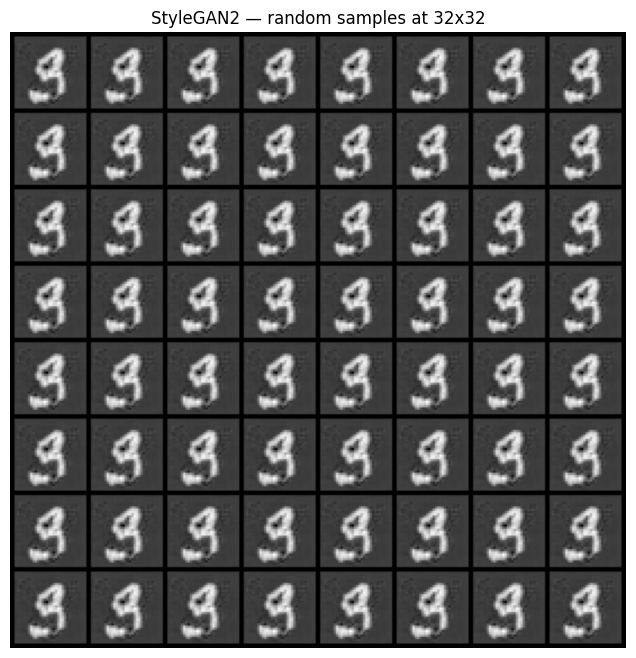

In [14]:
G.eval()
with torch.no_grad():
    samples = G(fixed_z)

grid = make_grid(samples.cpu(), nrow=8, normalize=True)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('StyleGAN2 — random samples at 32x32')
plt.show()

## 14. Latent Interpolation — Visible Effect of Path Length Regularization

Path length regularization is supposed to make the latent-to-image mapping **smoother**: interpolating linearly in `w` between two latents should produce a smooth visual interpolation.

Without PLR, you sometimes see sharp discontinuities mid-interpolation. With PLR, the transitions should look like a slow morph.

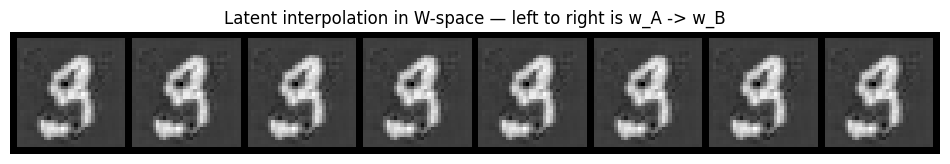

In [15]:
G.eval()
with torch.no_grad():
    z_a = torch.randn(1, latent_dim, device=device)
    z_b = torch.randn(1, latent_dim, device=device)
    w_a = G.mapping(z_a)
    w_b = G.mapping(z_b)
    alphas = torch.linspace(0, 1, 8, device=device)
    interp = torch.cat([(1 - a) * w_a + a * w_b for a in alphas], dim=0)
    imgs = G.synthesis(interp)

grid = make_grid(imgs.cpu(), nrow=8, normalize=True)
plt.figure(figsize=(12, 2.5))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap='gray')
plt.axis('off')
plt.title('Latent interpolation in W-space — left to right is w_A -> w_B')
plt.show()

## 15. Training Progression

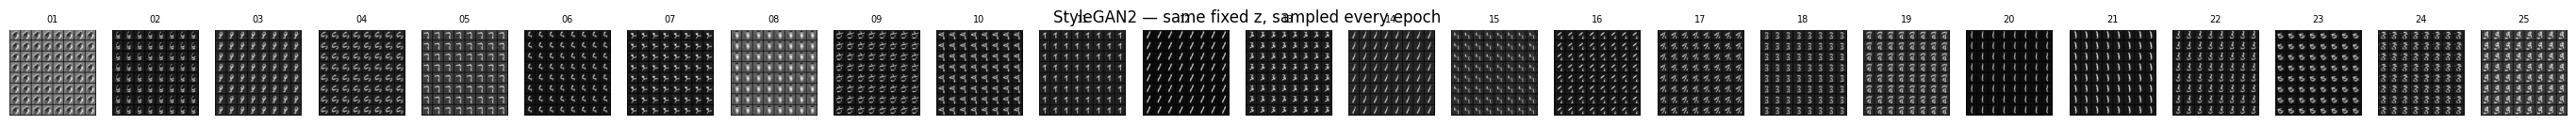

In [16]:
from PIL import Image
import glob

paths = sorted(glob.glob('samples_StyleGAN2/epoch_*.png'))
if paths:
    fig, axes = plt.subplots(1, len(paths), figsize=(1.4 * len(paths), 1.4))
    if len(paths) == 1:
        axes = [axes]
    for ax, p in zip(axes, paths):
        ax.imshow(np.array(Image.open(p)).squeeze(), cmap='gray')
        ax.set_title(p.split('_')[-1].split('.')[0], fontsize=7)
        ax.axis('off')
    plt.suptitle('StyleGAN2 — same fixed z, sampled every epoch')
    plt.show()
else:
    print('No sample grids found. Run the training cell first.')

## 16. Loss Curves and Path Length

Three traces worth watching:

- **D / G losses** — standard adversarial dynamics.
- **Path length** — should stabilize at a moderate value once training settles. If it grows unboundedly, `pl_weight` is probably too small. If it collapses to zero, the Generator may be ignoring `w`.
- **Running target `a_running`** — should track the actual path length closely.

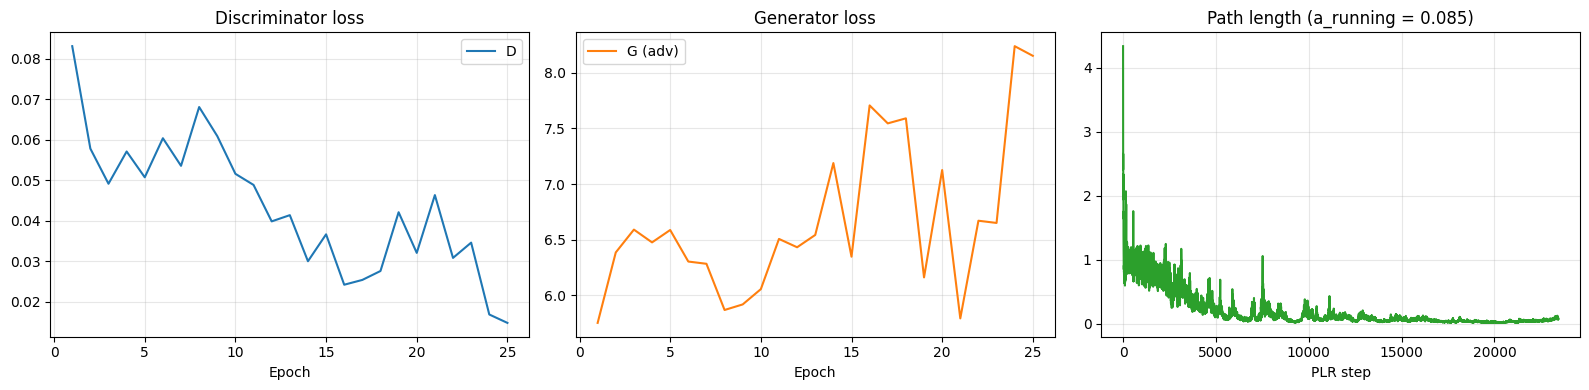

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(1, epochs + 1), losses_d, label='D', color='tab:blue')
axes[0].set_xlabel('Epoch')
axes[0].set_title('Discriminator loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, epochs + 1), losses_g, label='G (adv)', color='tab:orange')
axes[1].set_xlabel('Epoch')
axes[1].set_title('Generator loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

if pl_history:
    axes[2].plot(pl_history, color='tab:green')
    axes[2].set_xlabel('PLR step')
    axes[2].set_title(f'Path length (a_running = {a_running.item():.3f})')
    axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Recap — How StyleGAN2 Differs From StyleGAN

| Concern | StyleGAN | StyleGAN2 |
|---|---|---|
| Mapping network `z -> w` | yes | **yes** |
| Learned constant input | yes | **yes** |
| Style injection mechanism | **AdaIN** (modulates feature statistics) | **Weight modulation** (modulates conv weights) |
| Demodulation | none | **yes** (renormalize modulated weights) |
| Path length regularization | none | **yes** |
| Progressive growing | used | **removed** |
| Architecture changes during training | yes | **no** |
| Loss | adversarial BCE | **adversarial BCE + PLR penalty** |
| Style mixing | enabled | **enabled** |
**What changed and why.**

- **AdaIN discards information.** StyleGAN normalizes the activations and then injects style into the *normalized* features. The normalization can erase signal that the convolution produced. StyleGAN2 moves style control *into* the convolution, so the convolution sees the style from the start and doesn't have to fight a normalization step that runs after it.
- **Modulation gives style-controlled convolutions.** Scale each input channel's weights by a learned function of `w`. Different styles produce different convolutions applied to the same input. The Generator can specialize each style's effect on the convolution itself.
- **Demodulation prevents style-induced explosions.** Without it, a style that scales weights up would produce huge activations. Demodulation divides each output channel's weight by its L2 norm, keeping the effective weight scale ~1 regardless of style.
- **Path length regularization smooths the latent space.** Penalize the Generator when small changes in `w` produce inconsistent changes in image space. The running target `a_running` tracks the expected path length, so the penalty pushes the actual path length toward it.
- **No progressive growing.** The architecture is trained at the target resolution from the start. This simplifies the optimization landscape — no schedule boundaries to plan around, no mid-training architectural shifts.

**Common implementation pitfalls** — quick reference:

- **`F.unfold` + matmul instead of `F.conv2d`.** Because modulated weights are per-sample, the standard `F.conv2d` can't apply them in a single call. Use `F.unfold` to expand the input into per-kernel-position patches, then a batched matmul applies per-sample weights efficiently. Don't fall back to a Python loop over the batch — it will dominate training time.
- **Demodulation is per output channel, not per input channel.** The norm is computed across `in_ch * k * k` and divided into the per-output-channel weights. Easy to swap the axes by mistake.
- **PLR's `create_graph=True` is necessary.** Without it, `pl_penalty.backward()` won't reach the Generator's parameters. The cost is a slightly more expensive backward, but it's the only way the penalty actually updates anything.
- **Path length is averaged over the batch.** `grads.pow(2).sum(dim=1).sqrt().mean()` — sum per sample, then mean over batch. Not the other way around.
- **`a_running` is detached.** It tracks a running statistic, not a parameter. Don't let gradients flow into it. `.detach()` on `pl` before the EMA update is essential.
- **Don't apply PLR every iteration.** It's an extra forward + backward pass per application. Every 4 iterations is the StyleGAN2 default. More frequent is fine in principle, slower in practice.
- **Modulated weights are not BatchNorm-able.** The per-sample modulation produces per-sample weights. Don't try to apply BatchNorm after a modulated conv at the layer level — the modulation already handles the normalization job (via demodulation).

**Why StyleGAN2 was the right next step.** StyleGAN introduced the `z -> w` paradigm and proved that style-based synthesis could produce remarkably coherent images. But AdaIN had a cost: characteristic artifacts and lost signal in the feature pipeline. StyleGAN2 showed that you can keep all the *control* advantages of style-based synthesis while getting cleaner images and a simpler, more uniform architecture. It's the version of StyleGAN that most modern descendants build on.

**Next in the series** (Module 20): StyleGAN3. StyleGAN2's Generator still ties features to *fixed pixel coordinates* — it isn't truly translation or rotation equivariant. StyleGAN3 (alias-free GAN) treats the Generator as a continuous signal-processing system rather than a pixel-grid convnet, and addresses the resulting aliasing artifacts. That's the final major piece in the StyleGAN lineage covered by this roadmap.

In [18]:
import zipfile
import os
from google.colab import files

# Define the directory to be zipped
directory_to_zip = 'samples_StyleGAN2'
zip_file_name = f'{directory_to_zip}.zip'

# Create a ZipFile object
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_dir in os.walk(directory_to_zip):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            # Add file to zip, preserving directory structure
            zipf.write(file_path, os.path.relpath(file_path, directory_to_zip))

print(f"'{directory_to_zip}' has been successfully zipped into '{zip_file_name}'")

# Offer the zip file for download
files.download(zip_file_name)

'samples_StyleGAN2' has been successfully zipped into 'samples_StyleGAN2.zip'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>